In [26]:
import os
import datetime

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.nn import functional as F
from torchvision.utils import save_image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import h5py


In [ ]:
RESULTS_PATH = "./results"
DATASET = "dsprites" # dsprites / 3d_shapes
VAE_MODE = "beta" # normal / beta / factor

if DATASET not in ["3d_shapes", "dsprites"]:
    raise ValueError("DATASET must be one of 'dsprites', '3d_shapes'")

if VAE_MODE not in ["normal", "beta", "factor"]:
    raise ValueError("VAE_MODE must be one of 'normal', 'beta', 'factor'")

LOAD_MODEL = False
LOAD_MODEL_DIR = f"{VAE_MODE}_VAE_{DATASET}"
CHAMPION_MODEL_NAME = "champion"

IMG_WIDTH_HEIGHT = 64
NO_CHANNELS = 1 if DATASET == "dsprites" else 3
DISENTANGLEMENT_RANGE = [-3, 3]
DISENTANGLEMENT_STEPS = 10

LATENT_DIM = 10 if DATASET == "dsprites" else 6

if VAE_MODE == "beta":
    BETA = 4 if DATASET == "dsprites" else 32
else:
    BETA = 1

hyperparameters = {
    "device": 'cuda' if torch.cuda.is_available() else 'cpu',
    "train_val_split": 0.8,
    
    "lr": 1e-3,
    "batch_size": 128,
    "num_epochs": 1000,
    
    "log_interval": 100,
    
    "early_stopping_rounds": 5,
    "early_stopping_min_delta": 1e-2,
    
    "latent_dim": LATENT_DIM,
    "beta": BETA,
}

print("---SETTINGS---")
print(f"dataset: {DATASET}")
print(f"vae mode: {VAE_MODE}")
print(f"loading directory: {LOAD_MODEL_DIR}")

print("\n---HYPERPARAMETERS---")
for key, value in hyperparameters.items():
    print(f"{key}: {value}")

---SETTINGS---
dataset: 3d_shapes
vae mode: beta
loading directory: beta_VAE_3d_shapes

---HYPERPARAMETERS---
device: cuda
train_val_split: 0.8
lr: 0.001
batch_size: 128
num_epochs: 1000
log_interval: 100
early_stopping_rounds: 5
early_stopping_min_delta: 0.01
latent_dim: 6
beta: 32


# Loading Data

In [28]:
class DSpritesDataset(Dataset):
    def __init__(self, imgs):
        # imgs: numpy array (N, 64, 64)
        self.imgs = torch.from_numpy(imgs).float()  # to float32
        self.imgs = self.imgs.unsqueeze(1)  # (N, 1, 64, 64) → add channel dim

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        return self.imgs[idx]


class ShapesDataset(Dataset):
    def __init__(self, imgs):
        # imgs: numpy array (N, 64, 64, 3)
        self.imgs = torch.from_numpy(imgs / 255.).float() # to float32
        self.imgs = self.imgs.permute(0, 3, 1, 2) # (N, 3, 64, 64) → create channel first tensor

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        return self.imgs[idx]

In [29]:
# LOADING
if DATASET == "dsprites":
    dataset_zip = np.load('./data/dsprites_64x64.npz')
    dsprite_imgs = dataset_zip['imgs']
    images = dsprite_imgs.shape[0]

elif DATASET == "3d_shapes":
    _FACTORS_IN_ORDER = ['floor_hue', 'wall_hue', 'object_hue', 'scale', 'shape', 'orientation']
    _NUM_VALUES_PER_FACTOR = {'floor_hue': 10, 'wall_hue': 10, 'object_hue': 10, 'scale': 8, 'shape': 4, 'orientation': 15}
    shapes_dataset = h5py.File('./data/3d_shapes.h5', 'r')
    
    shapes_labels = shapes_dataset['labels']  # array shape [480000,6], float64
    batch_images = shapes_dataset['images']  # array shape [480000,64,64,3], uint8 in range(256)
    images = np.array(batch_images)
    
    shapes_image_shape = batch_images.shape[1:]  # [64,64,3]
    shapes_label_shape = shapes_labels.shape[1:]  # [6]
    n_samples = shapes_labels.shape[0]

else:
    raise ValueError("DATASET must be one of 'dsprites', '3d_shapes'")


# CREATE TRAIN AND TEST SPLIT
images_shuffled = images[np.random.permutation(n_samples)]

split = int(hyperparameters['train_val_split'] * n_samples)
train_imgs = images_shuffled[:split]
val_imgs  = images_shuffled[split:]


# CREATE DATALOADERS
if DATASET == "dsprites":
    train_loader = DataLoader(DSpritesDataset(train_imgs), batch_size=hyperparameters['batch_size'])
    val_loader = DataLoader(DSpritesDataset(val_imgs), batch_size=hyperparameters['batch_size'])

elif DATASET == "3d_shapes":
    train_loader = DataLoader(ShapesDataset(train_imgs), batch_size=hyperparameters['batch_size'])
    val_loader = DataLoader(ShapesDataset(val_imgs), batch_size=hyperparameters['batch_size'])

else:
    raise ValueError("DATASET must be one of 'dsprites', '3d_shapes'")


# Data Exploration

In [ ]:
def show_images_grid(imgs, num_images=25):
    imgs = imgs.detach().cpu()  # Sicherstellen, dass alles auf CPU ist
    ncols = int(np.ceil(num_images**0.5))
    nrows = int(np.ceil(num_images / ncols))
    _, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()

    for ax_i, ax in enumerate(axes):
        if ax_i < len(imgs):
            img = imgs[ax_i]

            if img.shape[0] == 3:  # RGB
                img = img.permute(1, 2, 0)  # CxHxW → HxWxC
                ax.imshow(img, interpolation='nearest')
            elif img.shape[0] == 1:  # Grayscale
                img = img.squeeze(0)  # 1xHxW → HxW
                ax.imshow(img, cmap='gray', interpolation='nearest')
            else:
                raise ValueError(f"Unerwartete Channel-Zahl: {img.shape[0]}")

            ax.set_xticks([])
            ax.set_yticks([])
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

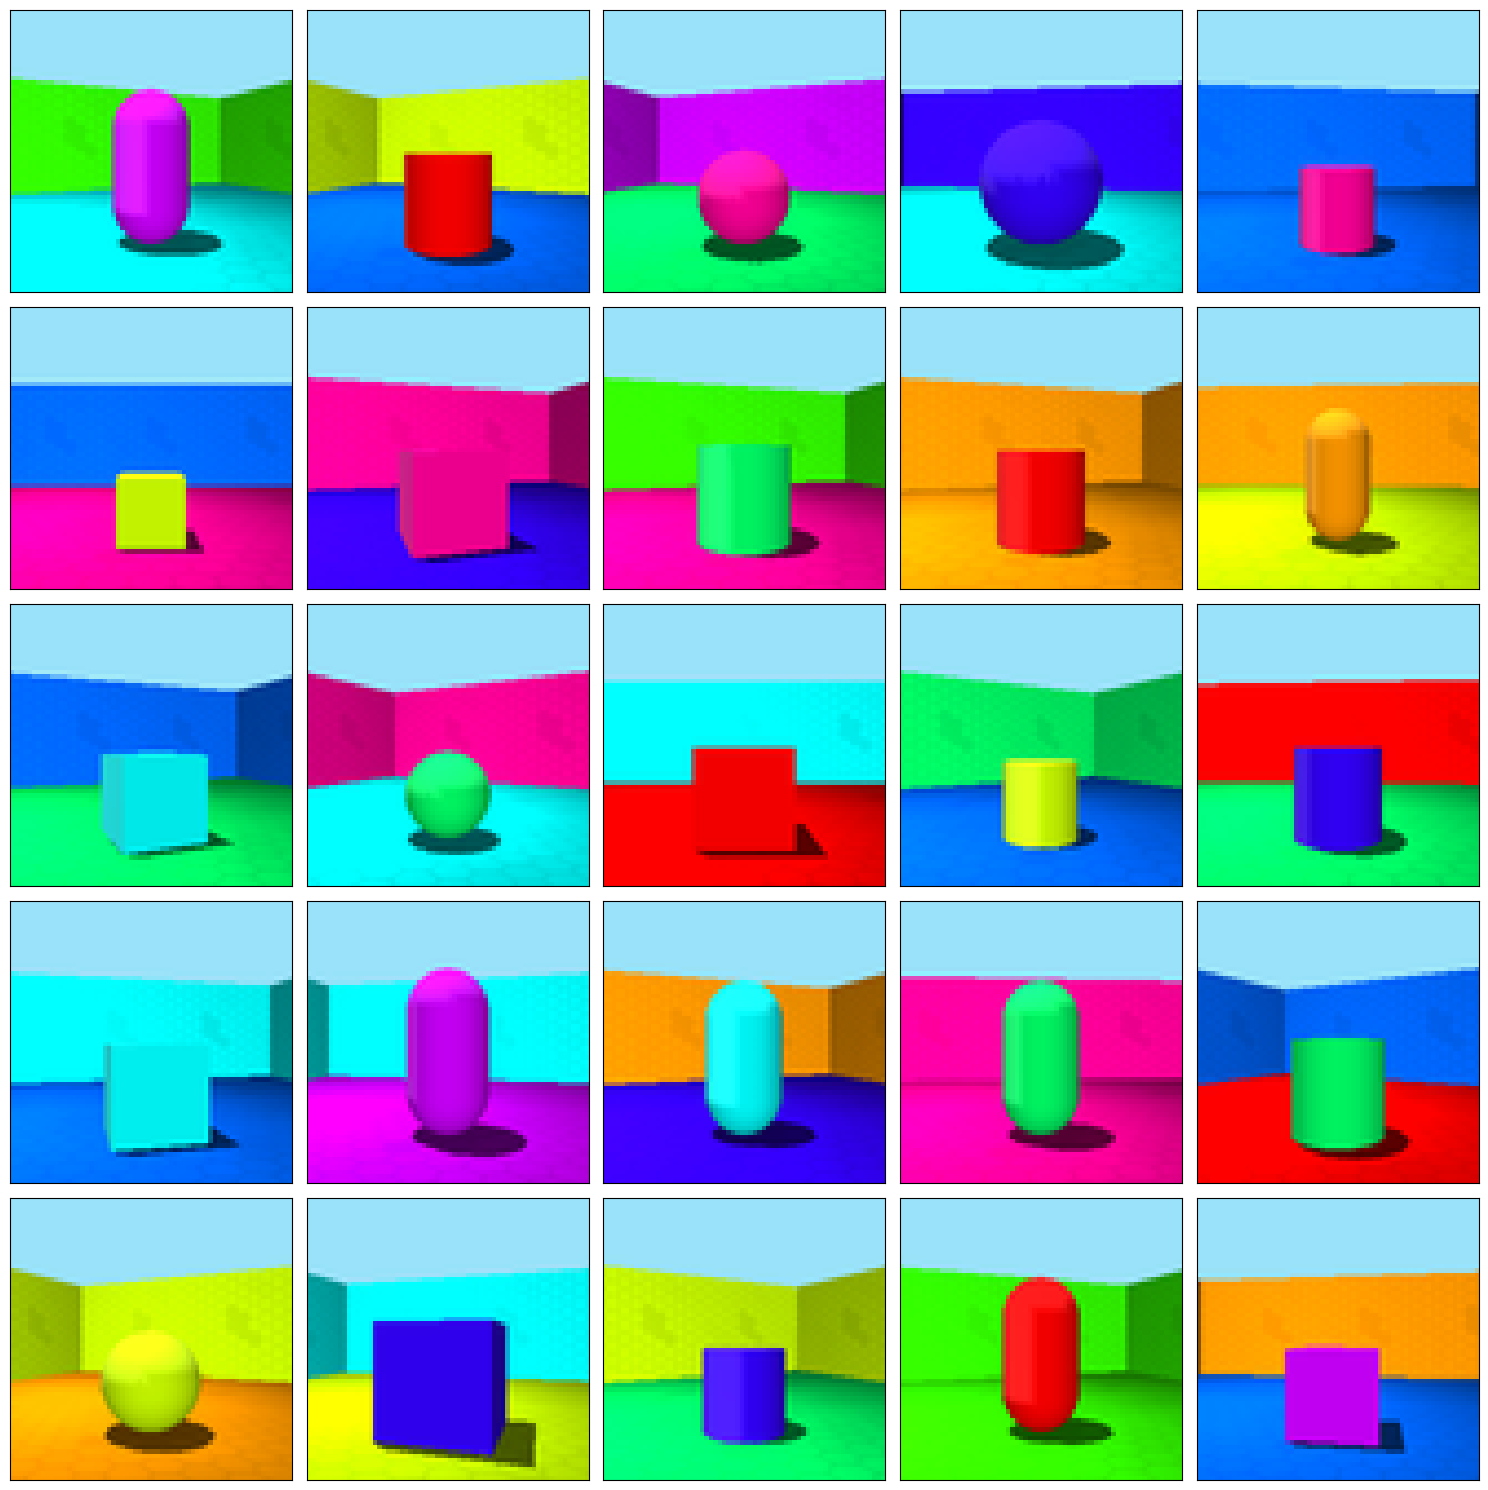

torch.Size([128, 3, 64, 64])

In [31]:
# Get a batch of images
dataiter = iter(train_loader)
batch_images = next(dataiter)

show_images_grid(batch_images)
batch_images.shape

# Models

In [53]:
# this architecture follows the proposed architecture from the Factor VAE paper
class VAE_dsprites(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),   # [B, 1, 64, 64] -> [B, 32, 32, 32]
            nn.ReLU(),
            nn.Conv2d(32, 32, 4, 2, 1),  # [B, 32, 32, 32] -> [B, 32, 16, 16]
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # -> [B, 64, 8, 8]
            nn.ReLU(),
            nn.Conv2d(64, 64, 4, 2, 1),  # -> [B, 64, 4, 4]
            nn.ReLU(),
            nn.Flatten(),               # -> [B, 64*4*4 = 1024]
            nn.Linear(1024, 128),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64 * 4 * 4),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 64, 4, 2, 1),  # -> [B, 64, 8, 8]
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # -> [B, 32, 16, 16]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 32, 4, 2, 1),  # -> [B, 32, 32, 32]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),   # -> [B, 1, 64, 64]
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = self.decoder_input(z).view(-1, 64, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [54]:
# this architecture follows the proposed architecture from the Factor VAE paper
class VAE_shapes(nn.Module):
    def __init__(self, latent_dim=6):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # [B, 3, 64, 64] -> [B, 32, 32, 32]
            nn.ReLU(),
            nn.Conv2d(32, 32, 4, 2, 1),  # -> [B, 32, 16, 16]
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # -> [B, 64, 8, 8]
            nn.ReLU(),
            nn.Conv2d(64, 64, 4, 2, 1),  # -> [B, 64, 4, 4]
            nn.ReLU(),
            nn.Flatten(),               # -> [B, 64*4*4 = 1024]
            nn.Linear(1024, 256),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64 * 4 * 4),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 64, 4, 2, 1),  # -> [B, 64, 8, 8]
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # -> [B, 32, 16, 16]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 32, 4, 2, 1),  # -> [B, 32, 32, 32]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),   # -> [B, 3, 64, 64]
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = self.decoder_input(z).view(-1, 64, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [55]:
if DATASET == "dsprites":
    print("using dsprites dataset")
    model = VAE_dsprites(latent_dim=hyperparameters['latent_dim']).to(hyperparameters['device'])
elif DATASET == "3d_shapes":
    print("using dsprites 3d_shapes dataset")
    model = VAE_shapes(latent_dim=hyperparameters['latent_dim']).to(hyperparameters['device'])
  
optimizer = optim.Adam(model.parameters(), lr=hyperparameters['lr'])

using dsprites 3d_shapes dataset


# Training functions

In [56]:
# Reconstruction + KL divergence losses summed over all elements and batch
def loss_function(recon_x, x, mu, logvar):
    # BCE = F.binary_cross_entropy(recon_x, x.view(-1, IMG_WIDTH_HEIGHT**2), reduction='sum')
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    # https://arxiv.org/abs/1312.6114
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) # -0.5 since we use logvar instead of sigma^2

    return BCE + hyperparameters['beta'] * KLD, BCE, hyperparameters['beta'] * KLD

def train(epoch):
    model.train()
    train_loss_total= train_bce_loss_total = train_kld_loss_total = 0
    for batch_idx, (data) in enumerate(train_loader): # (data, _) if label is present
        data = data.to(hyperparameters['device'])
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        # print(f"Reconstructed batch shape: {recon_batch.shape}, Data shape: {data.shape}")
        loss, bce_loss, kld_loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss_total += loss.item()
        train_bce_loss_total += bce_loss.item()
        train_kld_loss_total += kld_loss.item()
        optimizer.step()
        
        # Optional logging after certain log_interval
        # if batch_idx % hyperparameters['log_interval'] == 0:
        #     print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        #         epoch, batch_idx * len(data), len(train_loader.dataset),
        #         100. * batch_idx / len(train_loader),
        #         loss.item() / len(data)))


    print('====> Epoch: {} Average train loss: {:.4f}'.format(
          epoch, train_loss_total / len(train_loader.dataset)))
    
    return train_bce_loss_total / len(train_loader.dataset), train_kld_loss_total / len(train_loader.dataset)


def validate(epoch, result_save_path):
    model.eval()
    val_loss_total = val_bce_loss_total = val_kld_loss_total = 0
    with torch.no_grad():
        for i, (data) in enumerate(val_loader): 
            data = data.to(hyperparameters['device'])
            recon_batch, mu, logvar = model(data)
            loss, bce_loss, kld_loss = loss_function(recon_batch, data, mu, logvar)
            val_loss_total += loss.item()
            val_bce_loss_total += bce_loss.item()
            val_kld_loss_total += kld_loss.item()
            if i == 0:
                n = min(data.size(0), 8)
                comparison = torch.cat([data[:n], recon_batch.view(hyperparameters['batch_size'], NO_CHANNELS, IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT)[:n]])
                save_image(comparison.cpu(), os.path.join(result_save_path, f"reconstruction_{str(epoch)}.png"), nrow=n)

    val_loss_total /= len(val_loader.dataset)
    print('====> Epoch: {} Average validation loss: {:.4f}'.format(epoch, val_loss_total))

    return val_bce_loss_total / len(val_loader.dataset), val_kld_loss_total / len(val_loader.dataset)

# Training

In [57]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

def load_model(model, path):
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=hyperparameters['device']))
        print(f"Model loaded from {path}")
        return model
    else:
        print(f"Model file {path} does not exist.")

In [58]:
result_save_path = os.path.join(RESULTS_PATH, str(datetime.datetime.now()))
if not os.path.exists(result_save_path):
    os.makedirs(result_save_path)

train_bce_loss = []
train_kld_loss = []
val_bce_loss = []
val_kld_loss = []
no_epochs_no_improvement = 0
best_val_loss = np.inf

for epoch in range(1, hyperparameters['num_epochs'] + 1):
    train_losses = train(epoch)
    train_bce_loss.append(train_losses[0])
    train_kld_loss.append(train_losses[1])

    val_losses = validate(epoch, result_save_path)
    val_bce_loss.append(val_losses[0])
    val_kld_loss.append(val_losses[1])
    val_loss = val_losses[0] + val_losses[1]

    with torch.no_grad():
        sample = torch.randn(64, hyperparameters['latent_dim']).to(hyperparameters['device'])
        sample = model.decode(sample).cpu()
        save_image(sample.view(64, NO_CHANNELS, IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT), os.path.join(result_save_path, f"sample_{str(epoch)}.png"))
    
    # early stopping:
    if best_val_loss - val_loss > hyperparameters['early_stopping_min_delta']: # only when there is a real improvement
        save_model(model, os.path.join(result_save_path, f"{CHAMPION_MODEL_NAME}.pth"))
        no_epochs_no_improvement = 0
        best_val_loss = val_loss
    else:
        no_epochs_no_improvement += 1
        print(f"No improvement for {no_epochs_no_improvement} epochs.")
        if no_epochs_no_improvement >= hyperparameters['early_stopping_rounds']:
            print(f"No improvement for {no_epochs_no_improvement} epochs. Aborted training due to early stopping.")
            break

====> Epoch: 1 Average train loss: 4879.7295
====> Epoch: 1 Average validation loss: 4405.6412
====> Epoch: 2 Average train loss: 4350.7137
====> Epoch: 2 Average validation loss: 4316.4342
====> Epoch: 3 Average train loss: 4296.2309
====> Epoch: 3 Average validation loss: 4275.6939
====> Epoch: 4 Average train loss: 4249.8296
====> Epoch: 4 Average validation loss: 4229.7507
====> Epoch: 5 Average train loss: 4217.2790
====> Epoch: 5 Average validation loss: 4210.2188
====> Epoch: 6 Average train loss: 4194.5334
====> Epoch: 6 Average validation loss: 4182.5920
====> Epoch: 7 Average train loss: 4178.3796
====> Epoch: 7 Average validation loss: 4167.4330
====> Epoch: 8 Average train loss: 4167.5823
====> Epoch: 8 Average validation loss: 4157.4774
====> Epoch: 9 Average train loss: 4157.7597
====> Epoch: 9 Average validation loss: 4143.9381
====> Epoch: 10 Average train loss: 4144.8962
====> Epoch: 10 Average validation loss: 4135.2968
====> Epoch: 11 Average train loss: 4134.8183
==

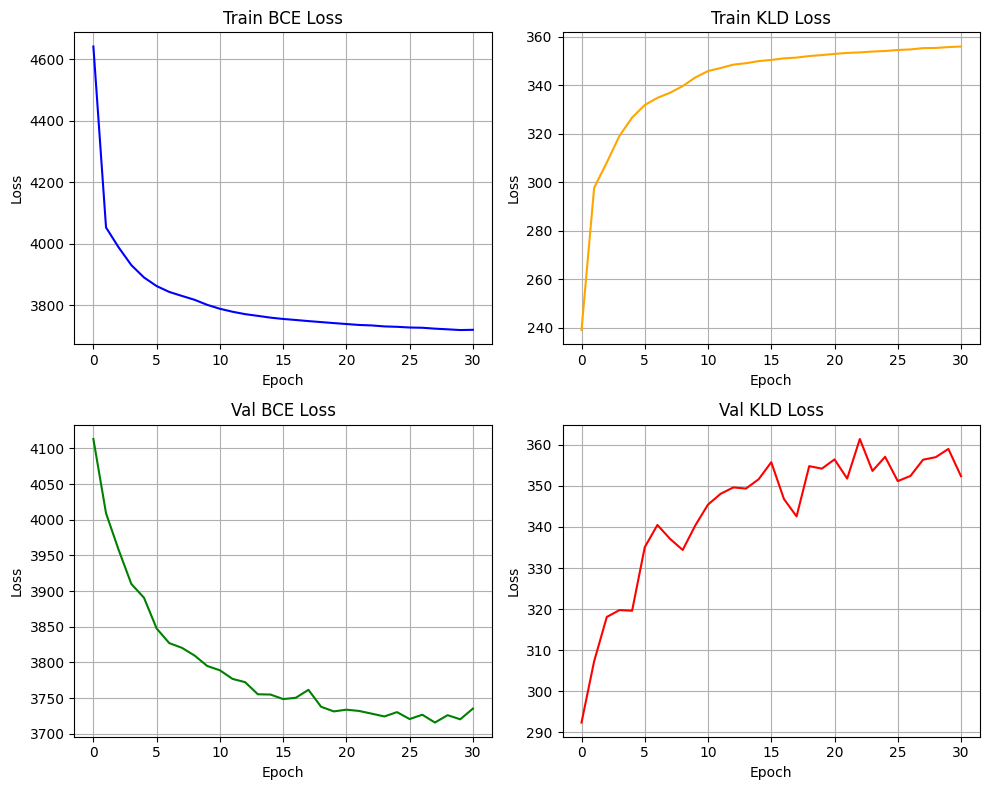

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
epochs = list(range(len(train_bce_loss)))

# 1: Train BCE
axs[0, 0].plot(epochs, train_bce_loss, label='Train BCE', color='blue')
axs[0, 0].set_title('Train BCE Loss')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)

# 2: Train KLD
axs[0, 1].plot(epochs, train_kld_loss, label='Train KLD', color='orange')
axs[0, 1].set_title('Train KLD Loss')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].grid(True)

# 3: Val BCE
axs[1, 0].plot(epochs, val_bce_loss, label='Val BCE', color='green')
axs[1, 0].set_title('Val BCE Loss')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].grid(True)

# 4: Val KLD
axs[1, 1].plot(epochs, val_kld_loss, label='Val KLD', color='red')
axs[1, 1].set_title('Val KLD Loss')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


# Visualization

Model loaded from ./results/beta_VAE_3d_shapes/champion.pth


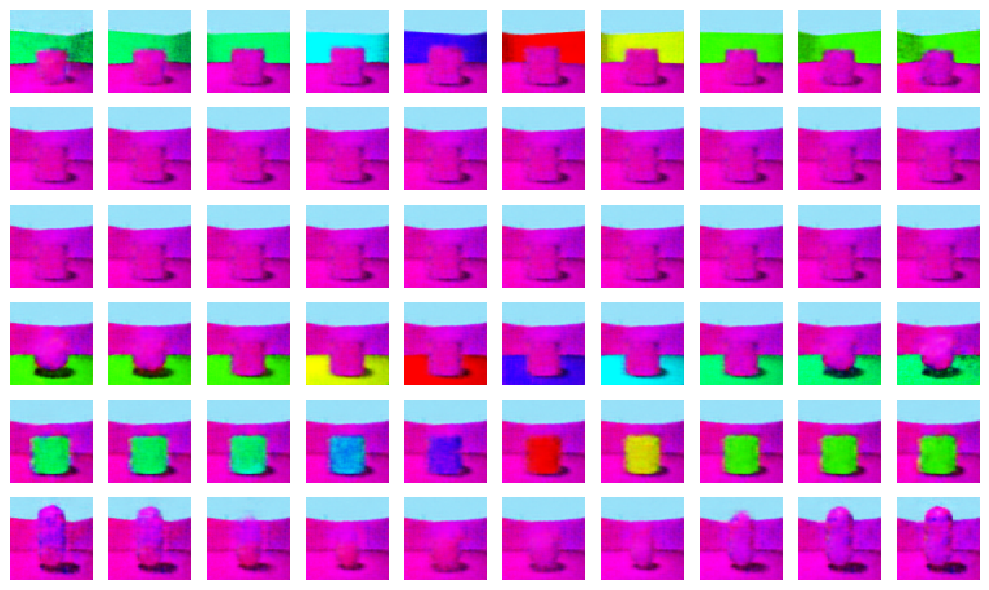

In [74]:
if LOAD_MODEL:
    if DATASET == "dsprites":
        model = load_model(VAE_dsprites(latent_dim=hyperparameters['latent_dim']), os.path.join(RESULTS_PATH, LOAD_MODEL_DIR, f"{CHAMPION_MODEL_NAME}.pth")).to(hyperparameters['device'])
    elif DATASET == "3d_shapes":
        model = load_model(VAE_shapes(latent_dim=hyperparameters['latent_dim']), os.path.join(RESULTS_PATH, LOAD_MODEL_DIR, f"{CHAMPION_MODEL_NAME}.pth")).to(hyperparameters['device'])
else:
    print("Not loading a model, using the trained model from the current run.")

test_viz_imgs = []
with torch.no_grad():
    z = torch.zeros(hyperparameters['latent_dim'])
    for z_param in range(hyperparameters['latent_dim']):
        row_imgs = []
        for val in torch.linspace(DISENTANGLEMENT_RANGE[0], DISENTANGLEMENT_RANGE[1], DISENTANGLEMENT_STEPS): # tensor with DISENTANGLEMENT_STEPS values ranging from DISENTANGLEMENT_RANGE[0] to DISENTANGLEMENT_RANGE[1]
            z_copy = z.clone().to(hyperparameters['device']) 
            z_copy[z_param] = val  # change one dimension of latent vector
            img = model.decode(z_copy.unsqueeze(0)) # decode latent vector and add batch dimension
            row_imgs.append(img.view(NO_CHANNELS, IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT).cpu().numpy()) 
        test_viz_imgs.append(row_imgs)
        

# Plot
fig, axes = plt.subplots(nrows=hyperparameters['latent_dim'], ncols=DISENTANGLEMENT_STEPS, figsize=(DISENTANGLEMENT_STEPS, hyperparameters['latent_dim']))

for dim in range(hyperparameters['latent_dim']):
    for step in range(DISENTANGLEMENT_STEPS):

        ax = axes[dim, step]

        # for RGB images
        if test_viz_imgs[dim][step].shape[0] == 3:
            test_viz_imgs[dim][step] = torch.tensor(test_viz_imgs[dim][step]).permute(1, 2, 0).numpy()  # CxHxW → HxWxC
            ax.imshow(test_viz_imgs[dim][step], interpolation='nearest')
        
        # for grayscale images
        elif test_viz_imgs[dim][step].shape[0] == 1:  # Grayscale
            test_viz_imgs[dim][step] = torch.tensor(test_viz_imgs[dim][step]).squeeze(0).numpy()  # 1xHxW → HxW
            ax.imshow(test_viz_imgs[dim][step], cmap='gray', interpolation='nearest')
        
        else:
            raise ValueError(f"Unexpected number of channels: {img.shape[0]}")
        
        ax.axis('off')

plt.tight_layout()
plt.show()